In [3]:
from pathlib import Path
import gc
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is unavailable and will be excluded.")

PROJECT_DIR = Path(r"D:\Sami Data Set")

INTERIM_DIR = PROJECT_DIR / "data" / "interim"
DOCUMENTATION_DIR = PROJECT_DIR / "documentation"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
MODELS_DIR = PROJECT_DIR / "models"
PREDICTIONS_DIR = PROJECT_DIR / "outputs" / "predictions"

for directory in [
    DOCUMENTATION_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    PREDICTIONS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

sample_path = (
    INTERIM_DIR
    / "candidate_feature_validation_sample.parquet"
)

selected_features_path = (
    DOCUMENTATION_DIR / "selected_feature_set.json"
)

if not sample_path.exists():
    raise FileNotFoundError(
        f"Validation sample not found:\n{sample_path}"
    )

if not selected_features_path.exists():
    raise FileNotFoundError(
        f"Selected feature file not found:\n"
        f"{selected_features_path}"
    )



print("Setup completed.")

Setup completed.


In [4]:
import sys
import pandas as pd
import sklearn
import joblib

print("Kernel working")
print("Python:", sys.version)
print("Environment:", sys.executable)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

Kernel working
Python: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]
Environment: D:\Sami Data Set\.venv\Scripts\python.exe
Pandas: 3.0.5
Scikit-learn: 1.9.0


In [5]:
from pathlib import Path

PROJECT_DIR = Path(r"D:\Sami Data Set")

required_files = {
    "Validation sample":
        PROJECT_DIR
        / "data"
        / "interim"
        / "candidate_feature_validation_sample.parquet",

    "Selected feature set":
        PROJECT_DIR
        / "documentation"
        / "selected_feature_set.json",

    "Feature validation results":
        PROJECT_DIR
        / "outputs"
        / "tables"
        / "candidate_feature_set_validation_results.csv"
}

for name, file_path in required_files.items():
    print(
        f"{name}:",
        "FOUND" if file_path.exists() else "MISSING",
        "|",
        file_path
    )

Validation sample: FOUND | D:\Sami Data Set\data\interim\candidate_feature_validation_sample.parquet
Selected feature set: FOUND | D:\Sami Data Set\documentation\selected_feature_set.json
Feature validation results: FOUND | D:\Sami Data Set\outputs\tables\candidate_feature_set_validation_results.csv


In [6]:
from pathlib import Path
import gc
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost available")
except Exception as error:
    XGBOOST_AVAILABLE = False
    print("XGBoost unavailable:", error)

PROJECT_DIR = Path(r"D:\Sami Data Set")

INTERIM_DIR = PROJECT_DIR / "data" / "interim"
DOCUMENTATION_DIR = PROJECT_DIR / "documentation"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
MODELS_DIR = PROJECT_DIR / "models"
PREDICTIONS_DIR = PROJECT_DIR / "outputs" / "predictions"

for directory in [
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    PREDICTIONS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

sample_path = (
    INTERIM_DIR
    / "candidate_feature_validation_sample.parquet"
)

selected_features_path = (
    DOCUMENTATION_DIR
    / "selected_feature_set.json"
)

print("Setup completed")
print("Sample exists:", sample_path.exists())
print("Feature file exists:", selected_features_path.exists())




XGBoost available
Setup completed
Sample exists: True
Feature file exists: True


In [7]:
with open(
    selected_features_path,
    "r",
    encoding="utf-8"
) as feature_file:
    selected_feature_information = json.load(feature_file)

selected_set_name = selected_feature_information[
    "selected_feature_set"
]

selected_features = selected_feature_information[
    "features"
]

required_columns = (
    selected_features
    + [
        "binary_label",
        "source_file_id",
        "source_row_id"
    ]
)

validation_sample = pd.read_parquet(
    sample_path,
    columns=required_columns
)

print("Selected set:", selected_set_name)
print("Selected features:", len(selected_features))
print("Loaded records:", f"{len(validation_sample):,}")
print("Loaded columns:", len(validation_sample.columns))

Selected set: top_20
Selected features: 20
Loaded records: 500,000
Loaded columns: 23


In [8]:
print(
    "Approximate DataFrame memory:",
    round(
        validation_sample.memory_usage(
            deep=True
        ).sum() / (1024 ** 2),
        2
    ),
    "MB"
)

Approximate DataFrame memory: 47.68 MB


In [9]:
X = validation_sample[selected_features].copy()

y = (
    validation_sample["binary_label"]
    .astype("int8")
    .copy()
)

metadata = validation_sample[
    ["source_file_id", "source_row_id"]
].copy()

for feature in selected_features:
    X[feature] = pd.to_numeric(
        X[feature],
        errors="raise"
    ).astype("float32")

if X.isna().any().any():
    raise ValueError(
        "Unexpected missing predictor values were found."
    )

(
    X_development,
    X_validation,
    y_development,
    y_validation,
    metadata_development,
    metadata_validation
) = train_test_split(
    X,
    y,
    metadata,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Development records:", f"{len(X_development):,}")
print("Validation records:", f"{len(X_validation):,}")

print("\nDevelopment class distribution:")
print(
    y_development
    .value_counts()
    .sort_index()
)

print("\nValidation class distribution:")
print(
    y_validation
    .value_counts()
    .sort_index()
)


Development records: 400,000
Validation records: 100,000

Development class distribution:
binary_label
0    320191
1     79809
Name: count, dtype: int64

Validation class distribution:
binary_label
0    80048
1    19952
Name: count, dtype: int64


In [10]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            solver="saga",
            penalty="l2",
            class_weight="balanced",
            max_iter=600,
            tol=1e-3,
            random_state=RANDOM_SEED
        )
    )
])

print("Training Logistic Regression...", flush=True)

start_time = time.time()

with warnings.catch_warnings(record=True) as logistic_warnings:
    warnings.simplefilter("always")

    logistic_model.fit(
        X_development,
        y_development
    )

training_seconds = time.time() - start_time

logistic_predictions = logistic_model.predict(
    X_validation
)

tn, fp, fn, tp = confusion_matrix(
    y_validation,
    logistic_predictions,
    labels=[0, 1]
).ravel()

logistic_accuracy = accuracy_score(
    y_validation,
    logistic_predictions
)

logistic_precision = precision_score(
    y_validation,
    logistic_predictions,
    pos_label=1,
    zero_division=0
)

logistic_recall = recall_score(
    y_validation,
    logistic_predictions,
    pos_label=1,
    zero_division=0
)

logistic_f1 = f1_score(
    y_validation,
    logistic_predictions,
    pos_label=1,
    zero_division=0
)

print("\nLogistic Regression completed")
print("Training time:", round(training_seconds, 2), "seconds")
print("Accuracy:", round(logistic_accuracy, 4))
print("Malicious precision:", round(logistic_precision, 4))
print("Malicious recall:", round(logistic_recall, 4))
print("Malicious F1-score:", round(logistic_f1, 4))
print("True negatives:", f"{tn:,}")
print("False positives:", f"{fp:,}")
print("False negatives:", f"{fn:,}")
print("True positives:", f"{tp:,}")
print("Warnings:", len(logistic_warnings))

joblib.dump(
    logistic_model,
    MODELS_DIR / "baseline_logistic_regression.joblib"
)

print("\nModel saved successfully.")


Training Logistic Regression...

Logistic Regression completed
Training time: 28.74 seconds
Accuracy: 0.8542
Malicious precision: 0.5838
Malicious recall: 0.9374
Malicious F1-score: 0.7195
True negatives: 66,712
False positives: 13,336
False negatives: 1,248
True positives: 18,704
Warnings: 1

Model saved successfully.


In [11]:
for warning in logistic_warnings:
    print(
        warning.category.__name__,
        ":",
        warning.message
    )


In [12]:
decision_tree_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_SEED
)

print("Training Decision Tree...", flush=True)

start_time = time.time()

decision_tree_model.fit(
    X_development,
    y_development
)

decision_tree_training_seconds = (
    time.time() - start_time
)

decision_tree_predictions = (
    decision_tree_model.predict(
        X_validation
    )
)

tn_dt, fp_dt, fn_dt, tp_dt = confusion_matrix(
    y_validation,
    decision_tree_predictions,
    labels=[0, 1]
).ravel()

decision_tree_accuracy = accuracy_score(
    y_validation,
    decision_tree_predictions
)

decision_tree_precision = precision_score(
    y_validation,
    decision_tree_predictions,
    pos_label=1,
    zero_division=0
)

decision_tree_recall = recall_score(
    y_validation,
    decision_tree_predictions,
    pos_label=1,
    zero_division=0
)

decision_tree_f1 = f1_score(
    y_validation,
    decision_tree_predictions,
    pos_label=1,
    zero_division=0
)

print("\nDecision Tree completed")
print(
    "Training time:",
    round(decision_tree_training_seconds, 2),
    "seconds"
)
print(
    "Accuracy:",
    round(decision_tree_accuracy, 4)
)
print(
    "Malicious precision:",
    round(decision_tree_precision, 4)
)
print(
    "Malicious recall:",
    round(decision_tree_recall, 4)
)
print(
    "Malicious F1-score:",
    round(decision_tree_f1, 4)
)
print("True negatives:", f"{tn_dt:,}")
print("False positives:", f"{fp_dt:,}")
print("False negatives:", f"{fn_dt:,}")
print("True positives:", f"{tp_dt:,}")

joblib.dump(
    decision_tree_model,
    MODELS_DIR / "baseline_decision_tree.joblib"
)

print("\nDecision Tree model saved successfully.")

Training Decision Tree...

Decision Tree completed
Training time: 15.56 seconds
Accuracy: 0.9633
Malicious precision: 0.8903
Malicious recall: 0.9305
Malicious F1-score: 0.91
True negatives: 77,761
False positives: 2,287
False negatives: 1,386
True positives: 18,566

Decision Tree model saved successfully.


In [13]:
random_forest_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

print("Training Random Forest...", flush=True)

start_time = time.time()

random_forest_model.fit(
    X_development,
    y_development
)

random_forest_training_seconds = (
    time.time() - start_time
)

random_forest_predictions = (
    random_forest_model.predict(
        X_validation
    )
)

tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(
    y_validation,
    random_forest_predictions,
    labels=[0, 1]
).ravel()

random_forest_accuracy = accuracy_score(
    y_validation,
    random_forest_predictions
)

random_forest_precision = precision_score(
    y_validation,
    random_forest_predictions,
    pos_label=1,
    zero_division=0
)

random_forest_recall = recall_score(
    y_validation,
    random_forest_predictions,
    pos_label=1,
    zero_division=0
)

random_forest_f1 = f1_score(
    y_validation,
    random_forest_predictions,
    pos_label=1,
    zero_division=0
)

print("\nRandom Forest completed")
print(
    "Training time:",
    round(random_forest_training_seconds, 2),
    "seconds"
)
print(
    "Accuracy:",
    round(random_forest_accuracy, 4)
)
print(
    "Malicious precision:",
    round(random_forest_precision, 4)
)
print(
    "Malicious recall:",
    round(random_forest_recall, 4)
)
print(
    "Malicious F1-score:",
    round(random_forest_f1, 4)
)
print("True negatives:", f"{tn_rf:,}")
print("False positives:", f"{fp_rf:,}")
print("False negatives:", f"{fn_rf:,}")
print("True positives:", f"{tp_rf:,}")

joblib.dump(
    random_forest_model,
    MODELS_DIR / "baseline_random_forest.joblib"
)

print("\nRandom Forest model saved successfully.")

Training Random Forest...

Random Forest completed
Training time: 111.02 seconds
Accuracy: 0.9805
Malicious precision: 0.9817
Malicious recall: 0.9195
Malicious F1-score: 0.9496
True negatives: 79,706
False positives: 342
False negatives: 1,606
True positives: 18,346

Random Forest model saved successfully.


In [14]:
class_counts = (
    y_development
    .value_counts()
    .sort_index()
)

benign_count = int(class_counts.get(0, 0))
malicious_count = int(class_counts.get(1, 0))

scale_pos_weight = (
    benign_count / malicious_count
)

print(
    "XGBoost scale_pos_weight:",
    round(scale_pos_weight, 4)
)

xgboost_model = XGBClassifier(
    n_estimators=150,
    max_depth=7,
    learning_rate=0.10,
    min_child_weight=2,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

print("Training XGBoost...", flush=True)

start_time = time.time()

xgboost_model.fit(
    X_development,
    y_development
)

xgboost_training_seconds = (
    time.time() - start_time
)

xgboost_predictions = xgboost_model.predict(
    X_validation
)

tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(
    y_validation,
    xgboost_predictions,
    labels=[0, 1]
).ravel()

xgboost_accuracy = accuracy_score(
    y_validation,
    xgboost_predictions
)

xgboost_precision = precision_score(
    y_validation,
    xgboost_predictions,
    pos_label=1,
    zero_division=0
)

xgboost_recall = recall_score(
    y_validation,
    xgboost_predictions,
    pos_label=1,
    zero_division=0
)

xgboost_f1 = f1_score(
    y_validation,
    xgboost_predictions,
    pos_label=1,
    zero_division=0
)

print("\nXGBoost completed")
print(
    "Training time:",
    round(xgboost_training_seconds, 2),
    "seconds"
)
print(
    "Accuracy:",
    round(xgboost_accuracy, 4)
)
print(
    "Malicious precision:",
    round(xgboost_precision, 4)
)
print(
    "Malicious recall:",
    round(xgboost_recall, 4)
)
print(
    "Malicious F1-score:",
    round(xgboost_f1, 4)
)
print("True negatives:", f"{tn_xgb:,}")
print("False positives:", f"{fp_xgb:,}")
print("False negatives:", f"{fn_xgb:,}")
print("True positives:", f"{tp_xgb:,}")

joblib.dump(
    xgboost_model,
    MODELS_DIR / "baseline_xgboost.joblib"
)

print("\nXGBoost model saved successfully.")



XGBoost scale_pos_weight: 4.012
Training XGBoost...

XGBoost completed
Training time: 13.04 seconds
Accuracy: 0.9803
Malicious precision: 0.9778
Malicious recall: 0.9222
Malicious F1-score: 0.9492
True negatives: 79,630
False positives: 418
False negatives: 1,552
True positives: 18,400

XGBoost model saved successfully.


In [15]:
baseline_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": logistic_accuracy,
        "malicious_precision": logistic_precision,
        "malicious_recall": logistic_recall,
        "malicious_f1": logistic_f1,
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "training_seconds": round(training_seconds, 2)
    },
    {
        "model": "Decision Tree",
        "accuracy": decision_tree_accuracy,
        "malicious_precision": decision_tree_precision,
        "malicious_recall": decision_tree_recall,
        "malicious_f1": decision_tree_f1,
        "true_negatives": int(tn_dt),
        "false_positives": int(fp_dt),
        "false_negatives": int(fn_dt),
        "true_positives": int(tp_dt),
        "training_seconds": round(
            decision_tree_training_seconds,
            2
        )
    },
    {
        "model": "Random Forest",
        "accuracy": random_forest_accuracy,
        "malicious_precision": random_forest_precision,
        "malicious_recall": random_forest_recall,
        "malicious_f1": random_forest_f1,
        "true_negatives": int(tn_rf),
        "false_positives": int(fp_rf),
        "false_negatives": int(fn_rf),
        "true_positives": int(tp_rf),
        "training_seconds": round(
            random_forest_training_seconds,
            2
        )
    },
    {
        "model": "XGBoost",
        "accuracy": xgboost_accuracy,
        "malicious_precision": xgboost_precision,
        "malicious_recall": xgboost_recall,
        "malicious_f1": xgboost_f1,
        "true_negatives": int(tn_xgb),
        "false_positives": int(fp_xgb),
        "false_negatives": int(fn_xgb),
        "true_positives": int(tp_xgb),
        "training_seconds": round(
            xgboost_training_seconds,
            2
        )
    }
])

baseline_results = baseline_results.sort_values(
    by=[
        "malicious_f1",
        "malicious_recall",
        "malicious_precision"
    ],
    ascending=[
        False,
        False,
        False
    ]
).reset_index(drop=True)

baseline_results["validation_rank"] = (
    range(1, len(baseline_results) + 1)
)

display(
    baseline_results[
        [
            "validation_rank",
            "model",
            "accuracy",
            "malicious_precision",
            "malicious_recall",
            "malicious_f1",
            "false_positives",
            "false_negatives",
            "training_seconds"
        ]
    ]
)

baseline_results.to_csv(
    TABLES_DIR / "baseline_model_validation_results.csv",
    index=False
)

print(
    "\nLeading baseline model:",
    baseline_results.loc[0, "model"]
)

print("Results saved successfully.")

,validation_rank,model,accuracy,malicious_precision,malicious_recall,malicious_f1,false_positives,false_negatives,training_seconds
0,1,Random Forest,0.98052,0.981699,0.919507,0.949586,342,1606,111.02
1,2,XGBoost,0.98030,0.977787,0.922213,0.949188,418,1552,13.04
2,3,Decision Tree,0.96327,0.890328,0.930533,0.909987,2287,1386,15.56
3,4,Logistic Regression,0.85416,0.583770,0.937450,0.719495,13336,1248,28.74



Leading baseline model: Random Forest
Results saved successfully.


In [16]:
baseline_selection_information = {
    "selected_feature_set": selected_set_name,
    "number_of_features": len(selected_features),
    "features": selected_features,
    "records_used": len(validation_sample),
    "development_records": len(X_development),
    "validation_records": len(X_validation),
    "models_compared": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "leading_baseline_model": (
        baseline_results.loc[0, "model"]
    ),
    "models_selected_for_tuning": [
        "Random Forest",
        "XGBoost"
    ],
    "selection_basis": (
        "Malicious-class F1-score followed by recall, "
        "precision, false-positive errors and efficiency"
    ),
    "final_test_set_used": False,
    "random_seed": RANDOM_SEED
}

with open(
    DOCUMENTATION_DIR
    / "baseline_model_selection.json",
    "w",
    encoding="utf-8"
) as selection_file:
    json.dump(
        baseline_selection_information,
        selection_file,
        indent=4
    )

print("Baseline selection documentation saved.")

Baseline selection documentation saved.


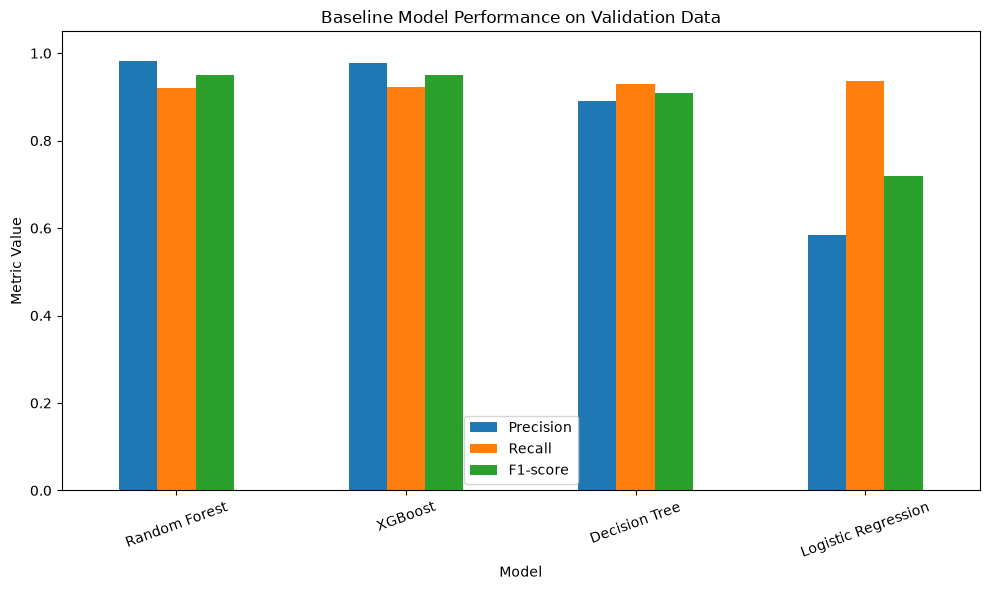

Figure saved to: D:\Sami Data Set\outputs\figures\baseline_model_performance_comparison.png


In [17]:
plot_data = baseline_results.set_index(
    "model"
)[
    [
        "malicious_precision",
        "malicious_recall",
        "malicious_f1"
    ]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Baseline Model Performance on Validation Data"
)
plt.xlabel("Model")
plt.ylabel("Metric Value")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(
    ["Precision", "Recall", "F1-score"]
)
plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / "baseline_model_performance_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Figure saved to:", figure_path)

## Baseline Model-Development Conclusion

Four supervised classifiers were compared using the same top-20
feature set and the same training-only development and validation
partitions. The frozen final test set was not accessed.

Random Forest achieved the highest malicious-class F1-score of 0.9496
and precision of 0.9817. XGBoost produced a closely comparable
F1-score of 0.9492, slightly higher recall of 0.9222 and a substantially
shorter training time of 13.04 seconds. Decision Tree achieved an
F1-score of 0.9100, while Logistic Regression provided the weakest
precision and F1-score despite its relatively high recall.

Because the difference between Random Forest and XGBoost was very
small, both models were retained for limited training-only
hyperparameter tuning. Final model selection will be completed before
the untouched test partition is opened.